In [485]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.special import airy

In [486]:
#CONSTANTS
c = 299792458.0
e = 1.60217663e-19
eps0 = 8.854187812e-12
m_e_MeV = 0.51099895

In [487]:
#ARES ENERGY PARAMETERS
E_MeV = 100
E_total = E_MeV + m_e_MeV
gamma = E_total / m_e_MeV
beta = np.sqrt(1 - 1 / gamma**2)
v = beta * c

In [488]:
#ARES CHARGE PARAMETERS
bunchcharge = 5e-12
Ne = bunchcharge/e

In [489]:
#BEAM PARAMETERS - OAM + GAUSSIAN
sigma_x = sigma_y = 1e-3

In [490]:
#TEMPORAL PULSE (in sec)
sigma_t = 1e-6

In [491]:
#SIGMA Z FOR GAUSSIAN
sigma_z = c * sigma_t

In [492]:
#OBSERVATION GRIDS
Nangle, Nlam = 200, 3000
th = np.linspace(-0.4, 0.4, Nangle)
lam = np.linspace(1e-7,1e-6, Nlam)
TH, LAM = np.meshgrid(th, lam, indexing='ij')
phi = np.linspace(0, 2*np.pi, Nangle, endpoint=False)
omega = 2*np.pi*c/lam

In [493]:
# #SINGLE ELECTRON SPECTRUM
A = e**2 / (4*np.pi * eps0 * c)
W1 = A*(beta**2 * np.sin(TH)**2) / (1.0 - beta**2 * np.cos(TH)**2)**2

In [494]:
#BUILDING GAUSSIAN DIST
z_g = np.linspace(-8*sigma_z, 8*sigma_z, 4096)
rho_g = np.exp(-0.5*(z/sigma_z)**2)

In [495]:
#BUILDING OAM DIST
def rho_oam_3d(x, y, z, sigma_t, sigma_z, l):
    r2 = x**2 + y**2
    return (r2**l) * np.exp(-r2 / sigma_t**2 - z**2 / sigma_z**2)

x_o = np.linspace(-sigma_t, sigma_t, 3000)
y_o = np.linspace(-sigma_t, sigma_t, 3000)
z_o = np.linspace(-sigma_z, sigma_z, 3000)   # plus or minus 1 mm
l=1
rho_o = rho_oam_3d(x_o, y_o, z_o, sigma_t, sigma_z, l)

In [496]:
#BUILDING AIRY DIST
def airy_beam_scaled(x, z, wavelength, x0=sigma_x, a=0.05):
    k = 2*np.pi/wavelength
    X, Z = np.meshgrid(x, z, indexing='ij')
    xi   = X / x0
    zeta = Z / (k * x0**2)
    arg  = xi - (zeta**2)/4 + 1j*a*zeta
    Ai, _, _, _ = airy(arg)
    phase = (xi*zeta)/2 - (zeta**3)/12
    amp   = a*(xi - (zeta**2)/2)

    psi = Ai * np.exp(amp + 1j*phase)
    return psi

x_a = np.linspace(-1e-3, 1e3, 3000)   # plus or minus 1 mm
z_a = np.linspace(0.0, 2.5, 3000)        # prop from 0m to 2.5 m
psi = airy_beam_scaled(x_a, z_a, lam, x0=2e-4)
rho_a = np.abs(psi)**2
rho_a /= rho_a.max()

C:\Users\gia-a\AppData\Local\Temp\ipykernel_17496\582497223.py:12: RuntimeWarning: overflow encountered in exp
  psi = Ai * np.exp(amp + 1j*phase)
C:\Users\gia-a\AppData\Local\Temp\ipykernel_17496\582497223.py:12: RuntimeWarning: invalid value encountered in exp
  psi = Ai * np.exp(amp + 1j*phase)
C:\Users\gia-a\AppData\Local\Temp\ipykernel_17496\582497223.py:12: RuntimeWarning: invalid value encountered in multiply
  psi = Ai * np.exp(amp + 1j*phase)


In [497]:
rho_a

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(3000, 3000))

In [499]:
#FORM FACTOR
def f2(omega, theta, rho_z, z, beta):
    dz = z[1] - z[0]
    rho = rho_z / np.trapezoid(rho_z, z)

    Rk = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(rho))) * dz
    kz = np.fft.fftshift(2*np.pi*np.fft.fftfreq(z.size, d=dz))

    Rk /= Rk[np.argmin(np.abs(kz))]

    k = omega / c
    kz_target = k[None, :] * (1.0/beta - np.cos(theta)[:, None])
    
    kz_flat = np.clip(kz_target.ravel(), kz[0], kz[-1])
    f2 = np.interp(kz_flat, kz, np.abs(Rk)**2).reshape(kz_target.shape)
    return f2

In [500]:
#CALCULATING BUNCH SPECTRUM
def electron_bunch_spectrum(W1, Ne, omega, th, rho_z, z, beta):
    Wn_list = []
    F2 = f2(omega, th, rho_z, z, beta)
    Wn_list.append(W1 * (Ne + Ne*(Ne-1)*F2))
    stack = np.stack(Wn_list, axis=0)
    positive = stack[stack > 0]
    vmin = np.percentile(positive, 1) if positive.size else 1e-30
    vmax = stack.max()
    
    return Wn_list, vmin, vmax, F2

In [501]:
Wn_list_g, vmin_g, vmax_g, F2_g = electron_bunch_spectrum(W1, Ne, omega, th, rho_g, z_g, beta)
Wn_list_o, vmin_o, vmax_o, F2_o = electron_bunch_spectrum(W1, Ne, omega, th, rho_o, z_o, beta)
Wn_list_a, vmin_a, vmax_a, F2_a = electron_bunch_spectrum(W1, Ne, omega, th, rho_a[0], z_a, beta)

C:\Users\gia-a\AppData\Local\Temp\ipykernel_17496\48786014.py:9: RuntimeWarning: invalid value encountered in divide
  Rk /= Rk[np.argmin(np.abs(kz))]


In [502]:
#PLOTTING
def plot_ctr_spectrum(th, lam, Wn_list, vmin, vmax, sigma_t):
    fig, ax = plt.subplots(figsize=(6,4))  
    im = ax.pcolormesh(th, lam, np.maximum(Wn_list[0].T, vmin), shading='auto', cmap='inferno', norm=LogNorm(vmin=vmin, vmax=vmax))
    
    ax.set_title(f'CTR \nPulse Duration \n = {sigma_t:.2e} s')
    ax.set_xlabel(r'$\theta$ (rad)')
    ax.set_ylabel(r'$\lambda$ (m)')
    ax.set_ylim(lam.min(), lam.max())
    
    cb = plt.colorbar(im, ax=ax)
    cb.set_label(r'$W_n$ (LogNorm)')

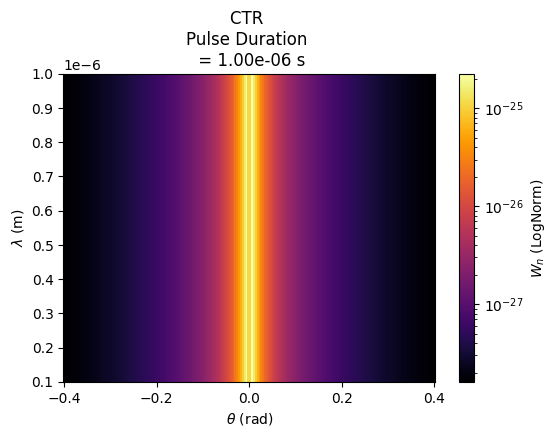

In [503]:
plot_ctr_spectrum(th, lam, Wn_list_g, vmin_g, vmax_g, sigma_t)

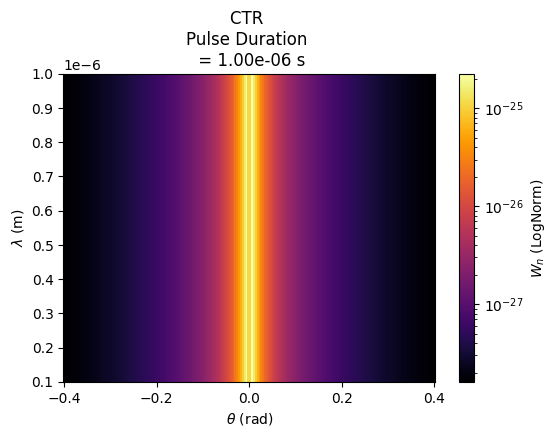

In [504]:
plot_ctr_spectrum(th, lam, Wn_list_o, vmin_o, vmax_o, sigma_t)

In [505]:
plot_ctr_spectrum(th, lam, Wn_list_a, vmin_a, vmax_a, sigma_t)

ValueError: Invalid vmin or vmax

Error in callback <function _draw_all_if_interactive at 0x0000016A9455B600> (for post_execute), with arguments args (),kwargs {}:


ValueError: Invalid vmin or vmax

ValueError: Invalid vmin or vmax

<Figure size 600x400 with 2 Axes>

In [ ]:
#INTEGRATION OF WN WITH RESPECT TO BIG OMEGA
jac = 2*np.pi*np.sin(TH)
Wn_int = [np.trapezoid(abs(Wn * jac), th, axis=0) for Wn in Wn_list]
ymax = max(w.max() for w in Wn_int)
Wn_int_array = np.array(Wn_int)

plt.figure(figsize=(6,4))
plt.plot(lam, Wn_int_array[0], label=f'{taus_fwhm_s_list:.0e} s')
plt.yscale('log')
plt.xlabel(r'$\lambda$ [m]')
plt.ylabel('Photon Count (Scaled)')
plt.legend()
plt.tight_layout()
plt.show()

ValueError: operands could not be broadcast together with shapes (1000,1000) (200,3000) 